In [1]:
# LOAD Packages 
import uproot
import pandas as pd
import numpy as np
import awkward as ak
!pip install awkward_pandas
!pip install torch
!pip install --upgrade typing_extensions
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
#matplotlib.rcParams.update(matplotlib.rcParamsDefault)
#matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt
import os
import math
import csv
import seaborn as sns
import sympy as smp
import sympy.stats
import json
import h5py
import sys
import glob
import yaml
from scipy import stats,signal,ndimage,special,fft
from scipy.optimize import curve_fit
from scipy.integrate import quad
from mpl_toolkits.axes_grid1 import make_axes_locatable
!pip install plotly
import plotly
import plotly.graph_objects as go

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


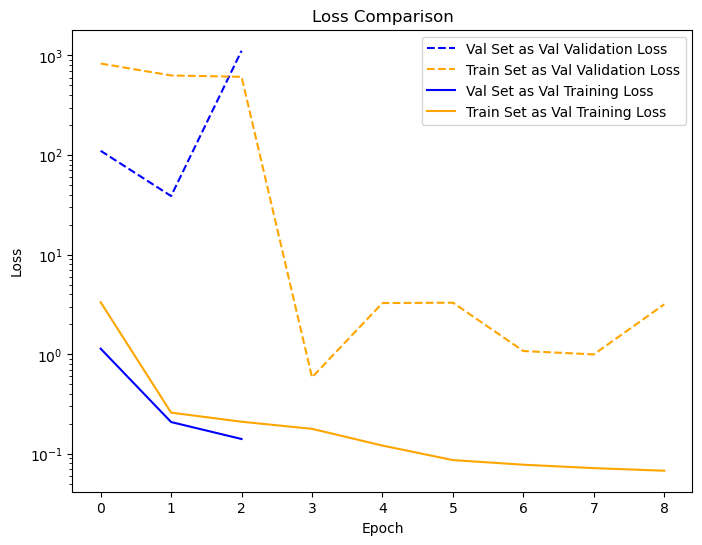

In [2]:
import csv

control_val_loss_csv = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-CONTROL/logs/ddp-shifter-batch-size-fix-val-loss-CONTROL_default_train_log.csv'
test_set_as_val_loss_csv = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-TEST_AS_VAL/logs/ddp-shifter-batch-size-fix-val-loss-TEST_AS_VAL_default_train_log.csv'

def plot_val_loss_comparison(control_csv, test_set_as_val_csv):

    control_epochs = []
    control_val_loss = []
    control_train_loss = []
    with open(control_csv, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            control_epochs.append(int(row['epoch']))
            control_val_loss.append(float(row['val_loss']))
            control_train_loss.append(float(row['train_loss']))

    train_epochs = []
    train_val_loss = []
    train_train_loss = []
    with open(test_set_as_val_csv, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            train_epochs.append(int(row['epoch']))
            train_val_loss.append(float(row['val_loss']))
            train_train_loss.append(float(row['train_loss']))

    fig, ax = plt.subplots(figsize=(8,6))
    ax.plot(control_epochs, control_val_loss, label='Val Set as Val Validation Loss', color='blue', linestyle='--')
    ax.plot(train_epochs, train_val_loss, label='Train Set as Val Validation Loss', color='orange', linestyle='--')
    ax.plot(control_epochs, control_train_loss, label='Val Set as Val Training Loss', color='blue', linestyle='-')
    ax.plot(train_epochs, train_train_loss, label='Train Set as Val Training Loss', color='orange', linestyle='-')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Loss Comparison')
    ax.legend()
    ax.set_yscale('log')
    plt.show()

plot_val_loss_comparison(control_val_loss_csv, test_set_as_val_loss_csv)

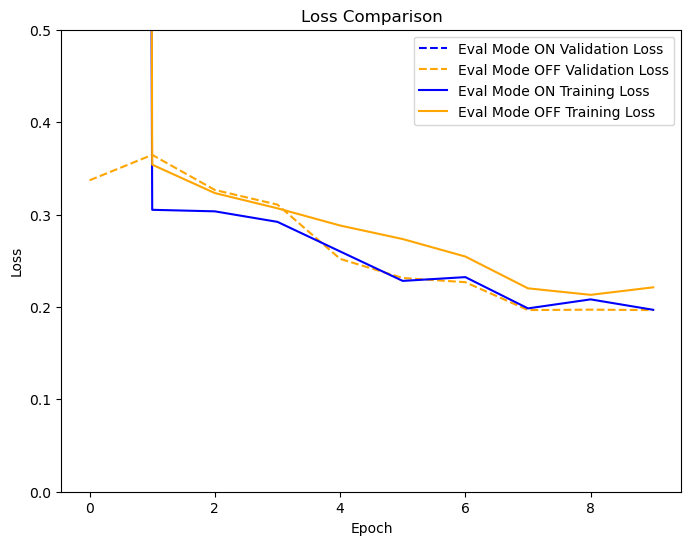

In [3]:
import csv

eval_mode_ON_loss_csv = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_CHECK_REPRO_3B/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_CHECK_REPRO_3B_default_train_log.csv'
eval_mode_OFF_loss_csv = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_OFF_3C/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_OFF_3C_default_train_log.csv'

def plot_val_loss_comparison(control_csv, eval_mode_off_csv):

    control_epochs = []
    control_val_loss = []
    control_train_loss = []
    with open(control_csv, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            control_epochs.append(int(row['epoch']))
            control_val_loss.append(float(row['val_loss']))
            control_train_loss.append(float(row['train_loss']))

    eval_mode_off_epochs = []
    eval_mode_off_val_loss = []
    eval_mode_off_train_loss = []
    with open(eval_mode_off_csv, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            eval_mode_off_epochs.append(int(row['epoch']))
            eval_mode_off_val_loss.append(float(row['val_loss']))
            eval_mode_off_train_loss.append(float(row['train_loss']))

    fig, ax = plt.subplots(figsize=(8,6))
    ax.plot(control_epochs, control_val_loss, label='Eval Mode ON Validation Loss', color='blue', linestyle='--')
    ax.plot(eval_mode_off_epochs, eval_mode_off_val_loss, label='Eval Mode OFF Validation Loss', color='orange', linestyle='--')
    ax.plot(control_epochs, control_train_loss, label='Eval Mode ON Training Loss', color='blue', linestyle='-')
    ax.plot(eval_mode_off_epochs, eval_mode_off_train_loss, label='Eval Mode OFF Training Loss', color='orange', linestyle='-')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Loss Comparison')
    ax.legend()
    ax.set_ylim(0, 0.5)
    #ax.set_yscale('log')
    plt.show()
    

plot_val_loss_comparison(eval_mode_ON_loss_csv, eval_mode_OFF_loss_csv)

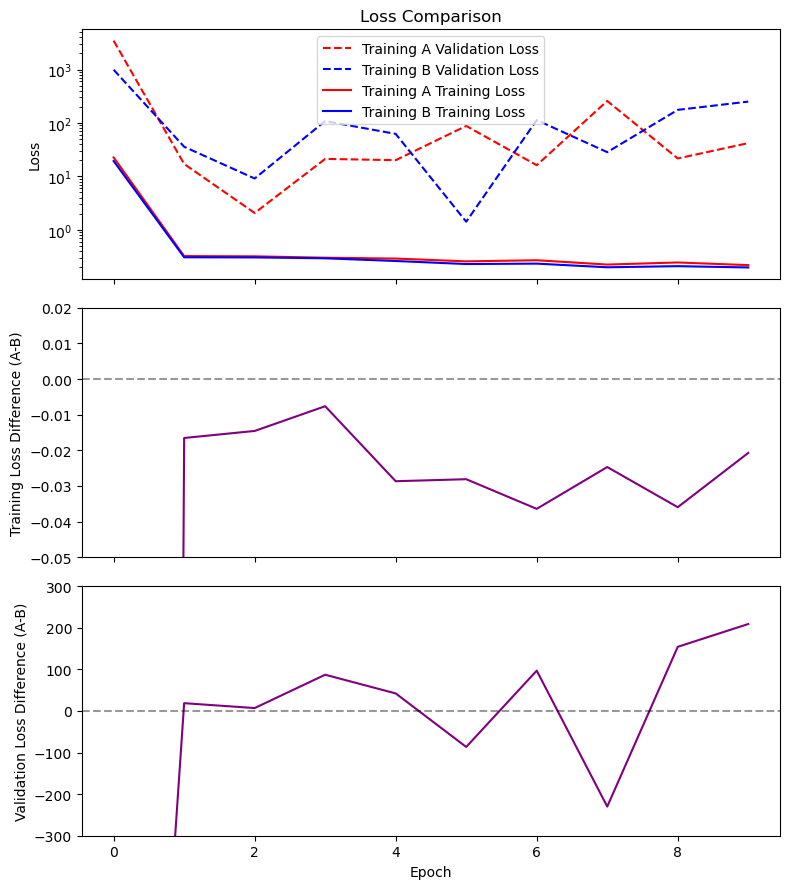

In [4]:
import csv

training_3A_loss_csv = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_CHECK_REPRO_3A/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_CHECK_REPRO_3A_default_train_log.csv'
training_3B_loss_csv = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_CHECK_REPRO_3B/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_CHECK_REPRO_3B_default_train_log.csv'

def plot_val_loss_comparison(control_csv, test_repro_csv):

    control_epochs = []
    control_val_loss = []
    control_train_loss = []
    with open(control_csv, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            control_epochs.append(int(row['epoch']))
            control_val_loss.append(float(row['val_loss']))
            control_train_loss.append(float(row['train_loss']))

    test_repro_epochs = []
    test_repro_val_loss = []
    test_repro_train_loss = []
    with open(test_repro_csv, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            test_repro_epochs.append(int(row['epoch']))
            test_repro_val_loss.append(float(row['val_loss']))
            test_repro_train_loss.append(float(row['train_loss']))

    fig, (ax, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
    ax.plot(control_epochs, control_val_loss, label='Training A Validation Loss', color='red', linestyle='--')
    ax.plot(test_repro_epochs, test_repro_val_loss, label='Training B Validation Loss', color='blue', linestyle='--')
    ax.plot(control_epochs, control_train_loss, label='Training A Training Loss', color='red', linestyle='-')
    ax.plot(test_repro_epochs, test_repro_train_loss, label='Training B Training Loss', color='blue', linestyle='-')
    #ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Loss Comparison')
    ax.legend()
    #ax.set_ylim(0, 0.5)
    ax.set_yscale('log')
    #plt.show()

    train_loss_diff = np.array(test_repro_train_loss) - np.array(control_train_loss)
    val_loss_diff = np.array(test_repro_val_loss) - np.array(control_val_loss)

    ax2.plot(control_epochs, train_loss_diff, color='purple', linestyle='-')
    #ax2.set_xlabel('Epoch')
    ax2.axhline(y=0, color='black', linestyle='--', alpha=0.4)
    ax2.set_ylabel('Training Loss Difference (A-B)')
    ax2.set_ylim(-0.05, 0.02)
    
    ax3.plot(control_epochs, val_loss_diff, color='purple', linestyle='-')
    ax3.axhline(y=0, color='black', linestyle='--', alpha=0.4)
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Validation Loss Difference (A-B)')
    ax3.set_ylim(-300, 300)

    fig.tight_layout()
    plt.show()

plot_val_loss_comparison(training_3A_loss_csv, training_3B_loss_csv)

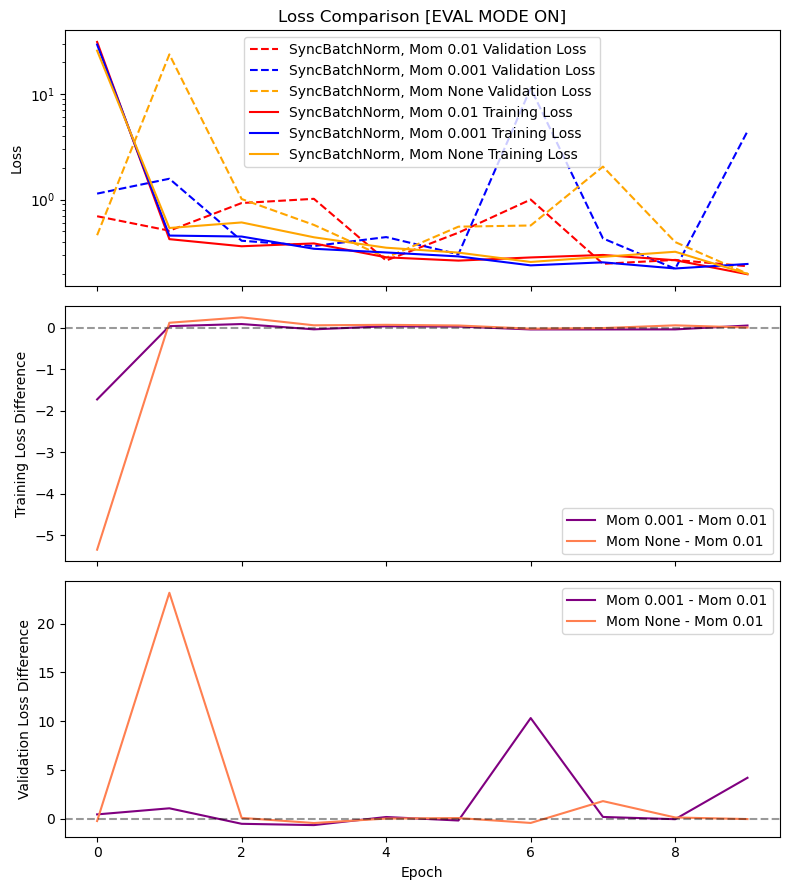

In [7]:
import csv

training_3A_loss_csv = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_SYNC_BN_MOMENTUM_0.01_4B/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_SYNC_BN_MOMENTUM_0.01_4B_default_train_log.csv'
#training_3B_loss_csv = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_OFF_3D/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_OFF_3D_default_train_log.csv'
#training_3B_loss_csv = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_SYNC_BN_4A/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_SYNC_BN_4A_default_train_log.csv'
training_3B_loss_csv = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_SYNC_BN_MOMENTUM_0.001_4C/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_SYNC_BN_MOMENTUM_0.001_4C_default_train_log.csv'
training_3C_loss_csv = '/global/cfs/cdirs/dune/users/ehinkle/nd_prototypes_ana/sheep-model/models/cnn/train_sheep_cnn_nersc/outputs/default/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_SYNC_BN_MOMENTUM_NONE_LOG_BN_STATS_FULL_4H/logs/ddp-shifter-batch-size-fix-val-loss-1250_SAMPLE_EVAL_MODE_ON_SYNC_BN_MOMENTUM_NONE_LOG_BN_STATS_FULL_4H_default_train_log.csv'

def plot_val_loss_comparison(control_csv, test_repro_csv, test_repro_csv_2):

    control_epochs = []
    control_val_loss = []
    control_train_loss = []
    with open(control_csv, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            control_epochs.append(int(row['epoch']))
            control_val_loss.append(float(row['val_loss']))
            control_train_loss.append(float(row['train_loss']))

    test_repro_epochs = []
    test_repro_val_loss = []
    test_repro_train_loss = []
    with open(test_repro_csv, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            test_repro_epochs.append(int(row['epoch']))
            test_repro_val_loss.append(float(row['val_loss']))
            test_repro_train_loss.append(float(row['train_loss']))

    test2_repro_epochs = []
    test2_repro_val_loss = []
    test2_repro_train_loss = []
    with open(test_repro_csv_2, 'r') as f:
        reader = csv.DictReader(f)
        for row in reader:
            test2_repro_epochs.append(int(row['epoch']))
            test2_repro_val_loss.append(float(row['val_loss']))
            test2_repro_train_loss.append(float(row['train_loss']))

    fig, (ax, ax2, ax3) = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
    ax.plot(control_epochs, control_val_loss, label='SyncBatchNorm, Mom 0.01 Validation Loss', color='red', linestyle='--')
    ax.plot(test_repro_epochs, test_repro_val_loss, label='SyncBatchNorm, Mom 0.001 Validation Loss', color='blue', linestyle='--')
    ax.plot(test2_repro_epochs[:10], test2_repro_val_loss[:10], label='SyncBatchNorm, Mom None Validation Loss', color='orange', linestyle='--')
    ax.plot(control_epochs, control_train_loss, label='SyncBatchNorm, Mom 0.01 Training Loss', color='red', linestyle='-')
    ax.plot(test_repro_epochs, test_repro_train_loss, label='SyncBatchNorm, Mom 0.001 Training Loss', color='blue', linestyle='-')
    ax.plot(test2_repro_epochs[:10], test2_repro_train_loss[:10], label='SyncBatchNorm, Mom None Training Loss', color='orange', linestyle='-')
    #ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title('Loss Comparison [EVAL MODE ON]')
    ax.legend()
    #ax.set_ylim(0, 0.5)
    ax.set_yscale('log')
    #plt.show()

    train_loss_diff = np.array(test_repro_train_loss) - np.array(control_train_loss)
    val_loss_diff = np.array(test_repro_val_loss) - np.array(control_val_loss)
    train_loss_diff2 = np.array(test2_repro_train_loss[:10]) - np.array(control_train_loss)
    val_loss_diff2 = np.array(test2_repro_val_loss[:10]) - np.array(control_val_loss)

    ax2.plot(control_epochs, train_loss_diff, color='purple', linestyle='-', label='Mom 0.001 - Mom 0.01')
    ax2.plot(control_epochs, train_loss_diff2, color='coral', linestyle='-', label='Mom None - Mom 0.01')
    #ax2.set_xlabel('Epoch')
    ax2.axhline(y=0, color='black', linestyle='--', alpha=0.4)
    ax2.set_ylabel('Training Loss Difference')
    ax2.legend()
    #ax2.set_ylim(-0.08, 0.08)
    
    ax3.plot(control_epochs, val_loss_diff, color='purple', linestyle='-', label='Mom 0.001 - Mom 0.01')
    ax3.plot(control_epochs, val_loss_diff2, color='coral', linestyle='-', label='Mom None - Mom 0.01')
    ax3.axhline(y=0, color='black', linestyle='--', alpha=0.4)
    ax3.set_xlabel('Epoch')
    ax3.legend()
    ax3.set_ylabel('Validation Loss Difference')
    #ax3.set_ylim(-300, 300)

    fig.tight_layout()
    plt.show()

plot_val_loss_comparison(training_3A_loss_csv, training_3B_loss_csv, training_3C_loss_csv)
plt.show()